# Eye Disease Classification



## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/EyeDiseaseDataset.zip /content/
!unzip -q /content/EyeDiseaseDataset.zip -d /content/data

In [ ]:
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 2. Dataset Exploring

In [ ]:
root = os.path.dirname(glob.glob('/content/data/**/metadata.csv', recursive=True)[0])
print(root)
print(os.listdir(root))
print(os.listdir(os.path.join(root, 'catalog')))
print(os.listdir(os.path.join(root, 'splits')))

/content/data
['catalog', 'Tasks_and_Classes.md', 'metadata.csv', 'splits', 'images']
['split_distribution.png', 'source_distribution.png', 'README.md', 'class_distribution.png', 'catalog_summary.csv']
['val.csv']


In [ ]:
with open(os.path.join(root, 'Tasks_and_Classes.md')) as f:
    print(f.read())

# Eye Disease Dataset: Available Tasks & Class Descriptions

This document outlines the computer vision and machine learning tasks that can be accomplished using the unified Eye Disease Dataset, along with a detailed medical description of the 8 disease classes present in the corpus.

---

## Part 1: Available Machine Learning Tasks

Given the scale (11,839 images), diversity (4 distinct data sources), and distribution of this dataset, you can perform several advanced machine learning tasks:

### 1. Multi-class Image Classification
The most direct application is training Convolutional Neural Networks (CNNs) like ResNet or DenseNet, or Vision Transformers (ViTs), to categorize a fundus image into one of the 8 discrete classes. This acts as a comprehensive diagnostic assistant.

### 2. Binary Screening (Disease vs. Normal)
You can subset the dataset to build highly specialized, high-accuracy binary classifiers. Examples include:
- **General Screening:** Normal vs. Abnormal (All other cla

In [ ]:
meta = pd.read_csv(os.path.join(root, 'metadata.csv'))
val_csv = pd.read_csv(os.path.join(root, 'splits', 'val.csv'))
summary = pd.read_csv(os.path.join(root, 'catalog', 'catalog_summary.csv'))

print(meta.shape, val_csv.shape)
print(meta.head())
print(val_csv.head())
print(summary)

(11839, 4) (1197, 4)
                  filename dataset unified_label original_label
0  ACRIMA_Im001_ACRIMA.jpg  ACRIMA        Normal         Normal
1  ACRIMA_Im002_ACRIMA.jpg  ACRIMA        Normal         Normal
2  ACRIMA_Im003_ACRIMA.jpg  ACRIMA        Normal         Normal
3  ACRIMA_Im004_ACRIMA.jpg  ACRIMA        Normal         Normal
4  ACRIMA_Im005_ACRIMA.jpg  ACRIMA        Normal         Normal
                  filename    dataset         unified_label original_label
0       ODIR_2634_left.jpg     ODIR5K                Normal              N
1       ODIR_982_right.jpg     ODIR5K                Others              O
2    APTOS_image_02639.png  APTOS2019  Diabetic Retinopathy             DR
3  ACRIMA_Im309_ACRIMA.jpg     ACRIMA                Normal         Normal
4      ODIR_2644_right.jpg     ODIR5K                Normal              N
                  Class  Total Images  Train  Val  Test
0                Normal          4698   3835  485   488
1  Diabetic Retinopathy          

The metadata columns are `filename` and `unified_label`. The images are matched by file name, and `val.csv`  has a `filename` column as well.

In [ ]:
FILE_COL = 'filename'
LABEL_COL = 'unified_label'

images_dir = os.path.join(root, 'images')
file_map = {f: os.path.join(d, f) for d, _, fs in os.walk(images_dir) for f in fs}

meta['name'] = meta[FILE_COL].astype(str).apply(os.path.basename)
meta['path'] = meta['name'].map(file_map)
print('missing image files:', meta['path'].isna().sum())
meta = meta.dropna(subset=['path']).reset_index(drop=True)

classes = sorted(meta[LABEL_COL].unique())
num_classes = len(classes)
class_names = [str(c) for c in classes]
meta['y'] = meta[LABEL_COL].map({c: i for i, c in enumerate(classes)})
print(num_classes, class_names)

missing image files: 0
8 ['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


## 3. Class distribution

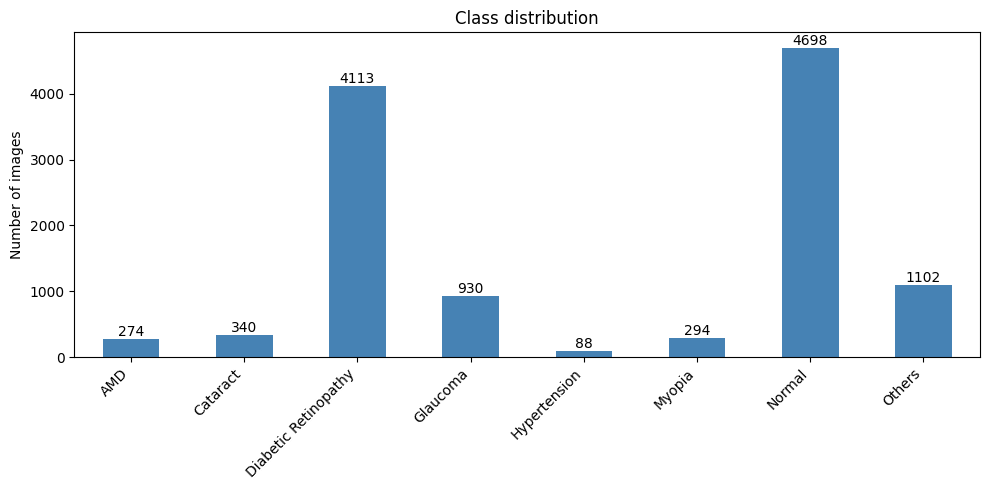

Imbalance ratio (max / min): 53.4


In [ ]:
counts = meta['y'].value_counts().sort_index()
counts.index = class_names

plt.figure(figsize=(10, 5))
ax = counts.plot(kind='bar', color='steelblue')
ax.bar_label(ax.containers[0])
plt.title('Class distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Imbalance ratio (max / min):', round(counts.max() / counts.min(), 1))

## 4. Sample images per class

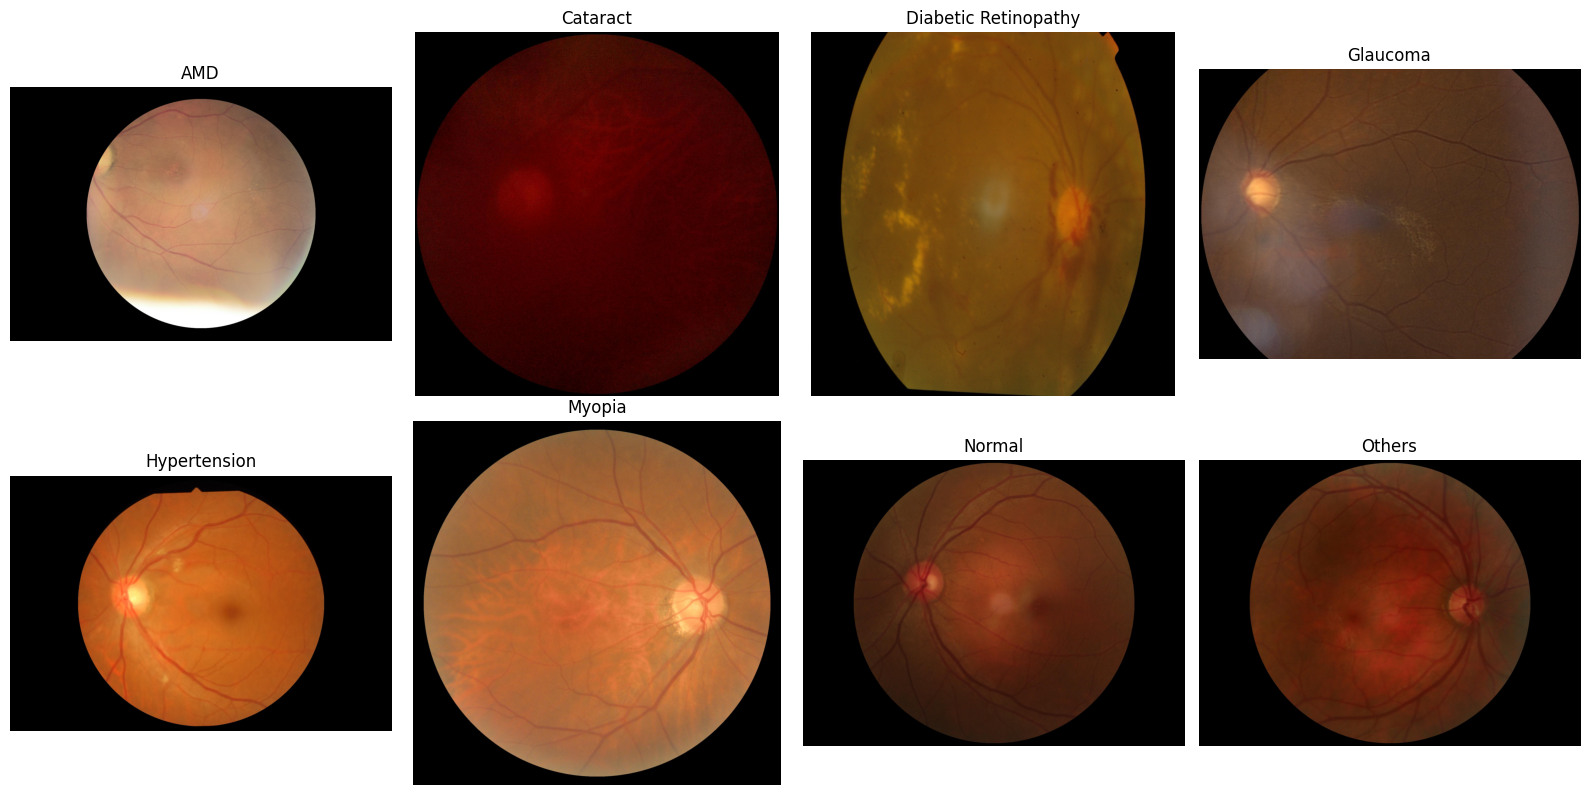

In [ ]:
plt.figure(figsize=(16, 8))
for i, c in enumerate(classes):
    row = meta[meta[LABEL_COL] == c].sample(1, random_state=SEED).iloc[0]
    plt.subplot(2, 4, i + 1)
    plt.imshow(Image.open(row['path']).convert('RGB'))
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Image boundaries

In [ ]:
sizes = []
for p in meta['path']:
    with Image.open(p) as im:
        sizes.append((im.width, im.height, im.mode))

size_df = pd.DataFrame(sizes, columns=['width', 'height', 'mode'])
size_df['ratio'] = size_df['width'] / size_df['height']

print(size_df[['width', 'height', 'ratio']].describe())
print(size_df['mode'].value_counts())
print(size_df.groupby(['width', 'height']).size().sort_values(ascending=False).head(10))

              width        height         ratio
count  11839.000000  11839.000000  11839.000000
mean    1804.145789   1415.201960      1.221410
std      942.329905    602.068855      0.241927
min      178.000000    178.000000      0.995280
25%     1000.000000   1000.000000      1.000000
50%     1936.000000   1444.000000      1.012658
75%     2592.000000   1728.000000      1.500000
max     5184.000000   3456.000000      2.150056
mode
RGB    11839
Name: count, dtype: int64
width  height
1000   1000      3485
2592   1728      2146
2048   1536       524
2304   1728       424
1956   1934       390
2736   1824       344
1936   1296       284
1444   1444       267
3456   2304       258
2976   1984       212
dtype: int64


In [ ]:
low, high = 255, 0
for p in meta['path'].sample(300, random_state=SEED):
    a = np.array(Image.open(p).convert('RGB'))
    low, high = min(low, int(a.min())), max(high, int(a.max()))
print('Pixel value range:', low, high)

Pixel value range: 0 255


Images vary in size, so every image is resized to 224x224 with 3 channels. Pixel values are in the 0-255 range and are scaled inside each model.

## 6. Splits

In [ ]:
val_names = set(val_csv[FILE_COL].astype(str).apply(os.path.basename))
val_df = meta[meta['name'].isin(val_names)]
rest = meta[~meta['name'].isin(val_names)]

train_df, test_df = train_test_split(
    rest, test_size=len(val_df) / len(rest), stratify=rest['y'], random_state=SEED)

split_table = pd.DataFrame({
    'train': train_df['y'].value_counts().sort_index(),
    'val': val_df['y'].value_counts().sort_index(),
    'test': test_df['y'].value_counts().sort_index()})
split_table.index = class_names
print(split_table)
print(len(train_df), len(val_df), len(test_df))

                      train  val  test
AMD                     218   28    28
Cataract                272   34    34
Diabetic Retinopathy   3272  426   415
Glaucoma                743   93    94
Hypertension             70    9     9
Myopia                  234   30    30
Normal                 3755  467   476
Others                  881  110   111
9445 1197 1197


## 7. Class imbalance handling

Balanced class weights are computed from the training set and passed to the loss during training.

In [ ]:
weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_df['y'])
class_weight = dict(enumerate(weights))
for i, w in class_weight.items():
    print(class_names[i], round(w, 2))

AMD 5.42
Cataract 4.34
Diabetic Retinopathy 0.36
Glaucoma 1.59
Hypertension 16.87
Myopia 5.05
Normal 0.31
Others 1.34


## 8. Input pipeline (tf.data)

In [ ]:
IMG = 224
BATCH = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG, IMG))
    return img, label

def make_ds(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((df['path'].values, df['y'].values))
    if training:
        ds = ds.shuffle(len(df), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(train_df, training=True)
val_ds = make_ds(val_df)
test_ds = make_ds(test_df)
y_test = test_df['y'].values

In [ ]:
def make_balanced_ds(df, training=True):
    per_class = [df[df['y'] == c] for c in range(num_classes)]
    datasets = []
    for sub in per_class:
        ds = tf.data.Dataset.from_tensor_slices((sub['path'].values, sub['y'].values))
        ds = ds.shuffle(len(sub), seed=SEED).repeat()
        ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
        datasets.append(ds)
    ds = tf.data.Dataset.sample_from_datasets(datasets, weights=[1 / num_classes] * num_classes)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

train_ds_balanced = make_balanced_ds(train_df)
steps_per_epoch = len(train_df) // BATCH

## 9. Helper functions

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

def plot_history(histories, title):
    loss = sum([h.history['loss'] for h in histories], [])
    val_loss = sum([h.history['val_loss'] for h in histories], [])
    acc = sum([h.history['accuracy'] for h in histories], [])
    val_acc = sum([h.history['val_accuracy'] for h in histories], [])
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(loss, label='train')
    plt.plot(val_loss, label='val')
    plt.title(title + ' loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(acc, label='train')
    plt.plot(val_acc, label='val')
    plt.title(title + ' accuracy')
    plt.xlabel('epoch')
    plt.legend()
    plt.show()

def evaluate(model, name):
    y_pred = model.predict(test_ds, verbose=0).argmax(axis=1)
    print(name)
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    return classification_report(y_test, y_pred, target_names=class_names,
                                 zero_division=0, output_dict=True)

def ms_per_image(model):
    x, _ = next(iter(test_ds))
    model.predict(x, verbose=0)
    start = time.time()
    for _ in range(10):
        model.predict(x, verbose=0)
    return (time.time() - start) / (10 * len(x)) * 1000

## 10. Model 1: CNN from scratch

In [ ]:
def build_cnn():
    return models.Sequential([
        layers.Input((IMG, IMG, 3)),
        layers.Rescaling(1 / 255),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')])

cnn = build_cnn()
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,792 (432.78 KB)

 Trainable params: 110,792 (432.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 182s 579ms/step - accuracy: 0.1477 - loss: 1.9366 - val_accuracy: 0.2414 - val_loss: 1.8589
Epoch 2/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 187s 557ms/step - accuracy: 0.1949 - loss: 1.8646 - val_accuracy: 0.2197 - val_loss: 1.8604
Epoch 3/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 199s 549ms/step - accuracy: 0.2078 - loss: 1.8251 - val_accuracy: 0.2047 - val_loss: 1.9875
Epoch 4/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 161s 543ms/step - accuracy: 0.2116 - loss: 1.7984 - val_accuracy: 0.2214 - val_loss: 1.8997
Epoch 5/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 162s 548ms/step - accuracy: 0.2443 - loss: 1.7448 - val_accuracy: 0.2456 - val_loss: 1.6414
Epoch 6/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 161s 544ms/step - accuracy: 0.2804 - loss: 1.6996 - val_accuracy: 0.2907 - val_loss: 1.7603
Epoch 7/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 201s 540ms/step - accuracy: 0.2970 - loss: 1.6799 - val_accuracy: 0.3183 - val_loss: 1.6002
Epoch 8/15
296/296 ━━━━━━━━━━━━━━━━━━━━ 161s 543ms/step - accuracy: 0.3112 -

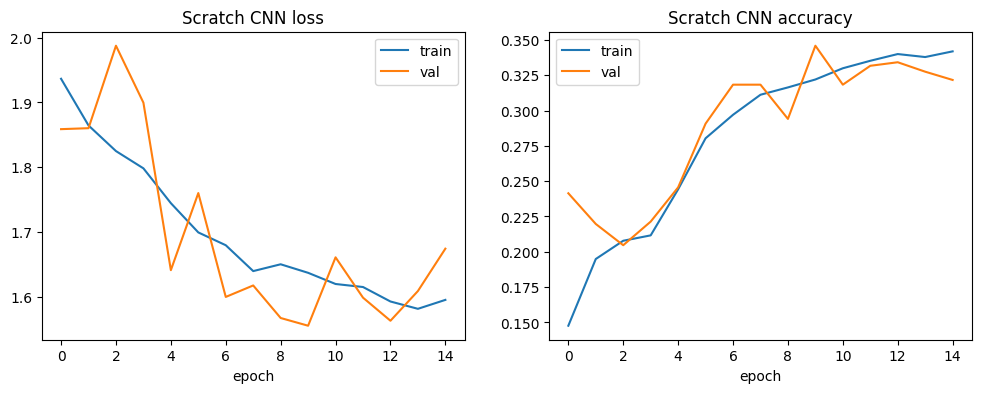

In [ ]:
cnn_hist = cnn.fit(train_ds, validation_data=val_ds, epochs=15,
                   class_weight=class_weight, callbacks=[early_stop])
plot_history([cnn_hist], 'Scratch CNN')

## 11. Model 2: fine-tuned EfficientNetB0

In [ ]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [ ]:
base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet',
                                            input_shape=(IMG, IMG, 3))
base.trainable = False

inputs = layers.Input((IMG, IMG, 3))
x = augment(inputs)
x = layers.Lambda(tf.keras.applications.efficientnet.preprocess_input)(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
effnet = models.Model(inputs, outputs)

effnet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Stage 1: train only the new classification head.

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)

eff_hist1 = effnet.fit(train_ds, validation_data=val_ds, epochs=5,
                       class_weight=class_weight, callbacks=[early_stop])

Epoch 1/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 185s 561ms/step - accuracy: 0.3930 - loss: 1.5334 - val_accuracy: 0.4403 - val_loss: 1.4314
Epoch 2/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 166s 559ms/step - accuracy: 0.4598 - loss: 1.2876 - val_accuracy: 0.5180 - val_loss: 1.2207
Epoch 3/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 202s 560ms/step - accuracy: 0.4717 - loss: 1.2529 - val_accuracy: 0.4904 - val_loss: 1.3078
Epoch 4/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 202s 560ms/step - accuracy: 0.4884 - loss: 1.2081 - val_accuracy: 0.4904 - val_loss: 1.3342
Epoch 5/5
296/296 ━━━━━━━━━━━━━━━━━━━━ 164s 553ms/step - accuracy: 0.4961 - loss: 1.1739 - val_accuracy: 0.5213 - val_loss: 1.3007


Stage 2: unfreeze the whole base of EfficientNetB0 and train with a small learning rate.

Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 216s 578ms/step - accuracy: 0.5934 - loss: 1.1500 - val_accuracy: 0.4987 - val_loss: 1.3579 - learning_rate: 1.0000e-04
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 170s 577ms/step - accuracy: 0.7083 - loss: 0.8314 - val_accuracy: 0.5731 - val_loss: 1.0915 - learning_rate: 1.0000e-04
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 189s 640ms/step - accuracy: 0.7570 - loss: 0.6775 - val_accuracy: 0.5923 - val_loss: 1.0453 - learning_rate: 1.0000e-04
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 169s 574ms/step - accuracy: 0.7904 - loss: 0.5731 - val_accuracy: 0.5840 - val_loss: 1.0225 - learning_rate: 1.0000e-04
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 169s 572ms/step - accuracy: 0.8262 - loss: 0.4890 - val_accuracy: 0.5881 - val_loss: 1.0276 - learning_rate: 1.0000e-04
Epoch 6/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 169s 574ms/step - accuracy: 0.8360 - loss: 0.4416 - val_accuracy: 0.5714 - val_loss: 1.1511 - learning_rate: 1.0000e-04
Epoch 7/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 

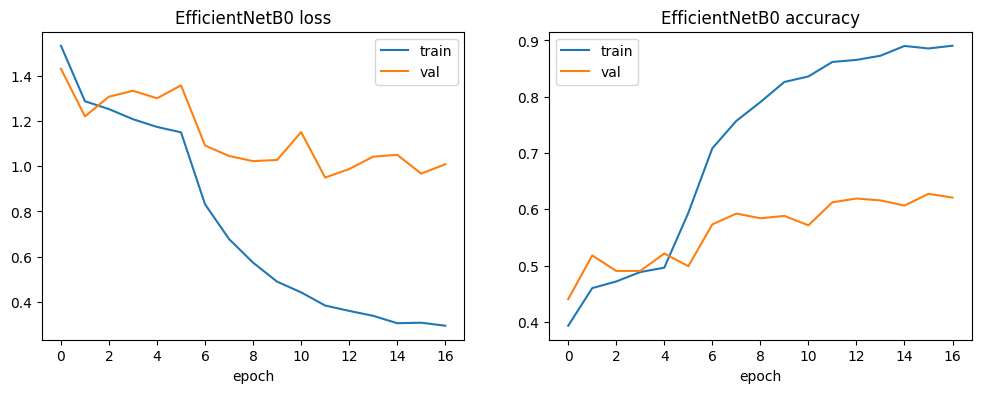

In [ ]:
base.trainable = True

effnet.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
               loss=tf.keras.losses.SparseCategoricalCrossentropy(),
               metrics=['accuracy'])
eff_hist2 = effnet.fit(train_ds_balanced, validation_data=val_ds, epochs=30,
                       steps_per_epoch=steps_per_epoch,
                       callbacks=[early_stop, reduce_lr])
plot_history([eff_hist1, eff_hist2], 'EfficientNetB0')

# Extra: Trying DenseNet121 Fine Tuning

In [ ]:
base = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet',
                                         input_shape=(IMG, IMG, 3))
base.trainable = False

inputs = layers.Input((IMG, IMG, 3))
x = augment(inputs)
x = layers.Lambda(tf.keras.applications.densenet.preprocess_input)(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
densenet = models.Model(inputs, outputs)

densenet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
dn_hist1 = densenet.fit(train_ds_balanced, validation_data=val_ds, epochs=5,
                        steps_per_epoch=steps_per_epoch, callbacks=[early_stop])

Epoch 1/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 195s 601ms/step - accuracy: 0.3897 - loss: 1.8289 - val_accuracy: 0.4043 - val_loss: 1.5779
Epoch 2/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 150s 510ms/step - accuracy: 0.4974 - loss: 1.4037 - val_accuracy: 0.4344 - val_loss: 1.4128
Epoch 3/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 150s 509ms/step - accuracy: 0.5235 - loss: 1.3304 - val_accuracy: 0.4628 - val_loss: 1.4100
Epoch 4/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 168s 571ms/step - accuracy: 0.5298 - loss: 1.3042 - val_accuracy: 0.4411 - val_loss: 1.4684
Epoch 5/5
295/295 ━━━━━━━━━━━━━━━━━━━━ 148s 501ms/step - accuracy: 0.5471 - loss: 1.2671 - val_accuracy: 0.4678 - val_loss: 1.3287


Epoch 1/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 181s 535ms/step - accuracy: 0.5173 - loss: 1.4211 - val_accuracy: 0.4637 - val_loss: 1.4752 - learning_rate: 1.0000e-04
Epoch 2/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 174s 592ms/step - accuracy: 0.5810 - loss: 1.2149 - val_accuracy: 0.5029 - val_loss: 1.3080 - learning_rate: 1.0000e-04
Epoch 3/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 173s 587ms/step - accuracy: 0.6161 - loss: 1.1127 - val_accuracy: 0.5138 - val_loss: 1.2639 - learning_rate: 5.0000e-05
Epoch 4/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 171s 581ms/step - accuracy: 0.6292 - loss: 1.0703 - val_accuracy: 0.5238 - val_loss: 1.2274 - learning_rate: 5.0000e-05
Epoch 5/30
295/295 ━━━━━━━━━━━━━━━━━━━━ 152s 515ms/step - accuracy: 0.6518 - loss: 1.0065 - val_accuracy: 0.5213 - val_loss: 1.2721 - learning_rate: 2.5000e-05


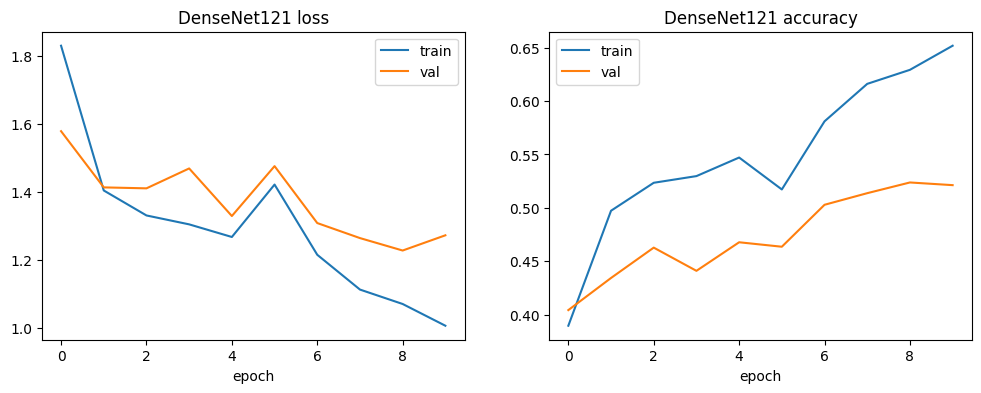

In [ ]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

densenet.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                 metrics=['accuracy'])
dn_hist2 = densenet.fit(train_ds_balanced, validation_data=val_ds, epochs=30,
                        steps_per_epoch=steps_per_epoch,
                        callbacks=[early_stop, reduce_lr])
plot_history([dn_hist1, dn_hist2], 'DenseNet121')

In [ ]:
dn_report = evaluate(densenet, 'Fine-tuned DenseNet121')

Fine-tuned DenseNet121
                      precision    recall  f1-score   support

                 AMD       0.14      0.64      0.23        28
            Cataract       0.35      0.91      0.50        34
Diabetic Retinopathy       0.97      0.38      0.54       415
            Glaucoma       0.42      0.66      0.51        94
        Hypertension       0.04      0.67      0.08         9
              Myopia       0.67      0.97      0.79        30
              Normal       0.80      0.44      0.56       476
              Others       0.17      0.35      0.23       111

            accuracy                           0.46      1197
           macro avg       0.45      0.63      0.43      1197
        weighted avg       0.73      0.46      0.51      1197



## 12. Evaluation with classification reports

In [ ]:
cnn_report = evaluate(cnn, 'Scratch CNN')

Scratch CNN
                      precision    recall  f1-score   support

                 AMD       0.03      0.07      0.04        28
            Cataract       0.06      0.74      0.11        34
Diabetic Retinopathy       0.76      0.41      0.54       415
            Glaucoma       0.62      0.43      0.50        94
        Hypertension       0.03      0.33      0.05         9
              Myopia       0.16      0.40      0.22        30
              Normal       0.74      0.30      0.43       476
              Others       0.12      0.05      0.08       111

            accuracy                           0.34      1197
           macro avg       0.31      0.34      0.25      1197
        weighted avg       0.62      0.34      0.41      1197



In [ ]:
eff_report = evaluate(effnet, 'Fine-tuned EfficientNetB0')

Fine-tuned EfficientNetB0
                      precision    recall  f1-score   support

                 AMD       0.32      0.43      0.37        28
            Cataract       0.69      0.79      0.74        34
Diabetic Retinopathy       0.95      0.51      0.66       415
            Glaucoma       0.60      0.71      0.65        94
        Hypertension       0.30      0.33      0.32         9
              Myopia       0.87      0.90      0.89        30
              Normal       0.70      0.73      0.72       476
              Others       0.25      0.58      0.35       111

            accuracy                           0.63      1197
           macro avg       0.59      0.62      0.59      1197
        weighted avg       0.73      0.63      0.65      1197



## 13. Model comparison

In [ ]:
comparison = pd.DataFrame({
    'Scratch CNN': [cnn_report['accuracy'], cnn_report['macro avg']['f1-score'],
                    cnn_report['weighted avg']['f1-score'],
                    cnn.count_params(), ms_per_image(cnn)],
    'EfficientNetB0': [eff_report['accuracy'], eff_report['macro avg']['f1-score'],
                 eff_report['weighted avg']['f1-score'],
                 effnet.count_params(), ms_per_image(effnet)]},
    index=['accuracy', 'macro F1', 'weighted F1', 'parameters', 'ms per image'])
print(comparison.round(4))

              Scratch CNN  EfficientNetB0
accuracy           0.3358    6.332000e-01
macro F1           0.2460    5.866000e-01
weighted F1        0.4120    6.523000e-01
parameters    110792.0000    4.059819e+06
ms per image       3.1995    5.169500e+00


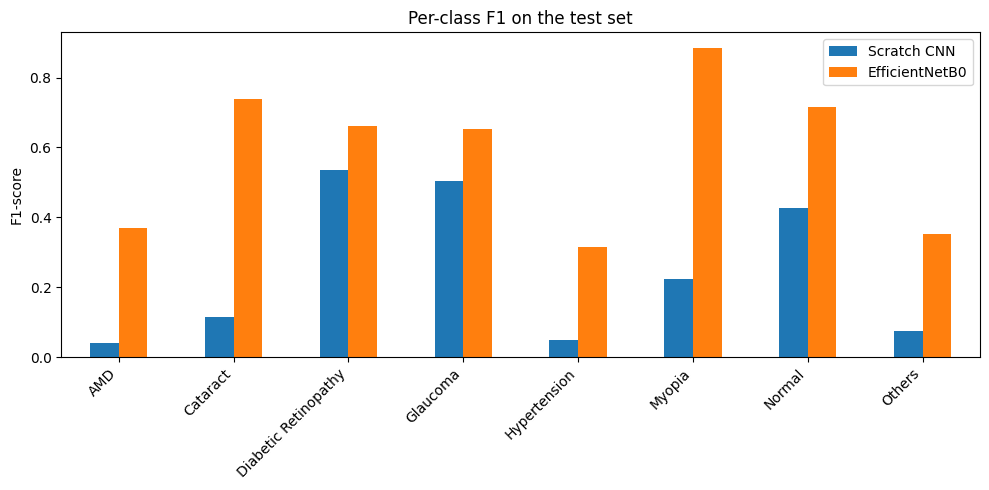

                      train images  test images  Scratch CNN  EfficientNetB0
AMD                            218           28        0.040           0.369
Cataract                       272           34        0.114           0.740
Diabetic Retinopathy          3272          415        0.535           0.661
Glaucoma                       743           94        0.503           0.654
Hypertension                    70            9        0.050           0.316
Myopia                         234           30        0.224           0.885
Normal                        3755          476        0.427           0.716
Others                         881          111        0.075           0.352


In [ ]:
f1 = pd.DataFrame({
    'Scratch CNN': [cnn_report[c]['f1-score'] for c in class_names],
    'EfficientNetB0': [eff_report[c]['f1-score'] for c in class_names]}, index=class_names)
f1.plot(kind='bar', figsize=(10, 5))
plt.title('Per-class F1 on the test set')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'train images': split_table['train'], 'test images': split_table['test']}).join(f1.round(3)))

## 14. Final Report

**Scratch CNN**

*   The imbalanced data classes is actually a big problem in here so first I handled them with giving the classes diffrent initial weights so the most rare class have the biggest weight and that what I used only in the scrach cnn model.
*   The scrach cnn model does not perform well as expected.
*   34% Accuracy


**Fine-Tuned EfficientNetB0**



*   For the imbalanced classes augmentation work the best so I added it to the model training only to avoid data leakage
*   The pre-tained model EfficientNetB0 made an improvement for the val_acuuracy and per class performance
*   63% Accuracy and F1 score per class is better way more than cnn.



